In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# Create folder structure
os.makedirs("../data", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

print("✓ All libraries loaded")
print("✓ Folder structure ready")
print(f"  GeoPandas: {gpd.__version__}")
print(f"  OSMnx: {ox.__version__}")

✓ All libraries loaded
✓ Folder structure ready
  GeoPandas: 1.1.3
  OSMnx: 2.1.0


In [2]:
# All 33 Gujarat districts
district_queries = {
    "Ahmedabad": "Ahmedabad district, Gujarat, India",
    "Surat": "Surat district, Gujarat, India",
    "Vadodara": "Vadodara district, Gujarat, India",
    "Rajkot": "Rajkot district, Gujarat, India",
    "Gandhinagar": "Gandhinagar district, Gujarat, India",
    "Bhavnagar": "Bhavnagar district, Gujarat, India",
    "Jamnagar": "Jamnagar district, Gujarat, India",
    "Junagadh": "Junagadh district, Gujarat, India",
    "Anand": "Anand district, Gujarat, India",
    "Mehsana": "Mahesana district, Gujarat, India",
    "Bharuch": "Bharuch district, Gujarat, India",
    "Navsari": "Navsari district, Gujarat, India",
    "Valsad": "Valsad district, Gujarat, India",
    "Kutch": "Kutch district, Gujarat, India",
    "Patan": "Patan district, Gujarat, India",
    "Banaskantha": "Banaskantha district, Gujarat, India",
    "Sabarkantha": "Sabarkantha district, Gujarat, India",
    "Aravalli": "Aravalli district, Gujarat, India",
    "Kheda": "Kheda district, Gujarat, India",
    "Mahisagar": "Mahisagar district, Gujarat, India",
    "Chhota Udaipur": "Chhota Udaipur district, Gujarat, India",
    "Dahod": "Dahod district, Gujarat, India",
    "Panchmahals": "Panch Mahals district, Gujarat, India",
    "Vadodara Rural": "Vadodara district, Gujarat, India",
    "Narmada": "Narmada district, Gujarat, India",
    "Tapi": "Tapi district, Gujarat, India",
    "Dang": "Dang district, Gujarat, India",
    "Amreli": "Amreli district, Gujarat, India",
    "Gir Somnath": "Gir Somnath district, Gujarat, India",
    "Botad": "Botad district, Gujarat, India",
    "Devbhumi Dwarka": "Devbhumi Dwarka district, Gujarat, India",
    "Morbi": "Morbi district, Gujarat, India",
    "Porbandar": "Porbandar district, Gujarat, India"
}

print(f"Total districts to fetch: {len(district_queries)}")

results = []
for name, query in district_queries.items():
    try:
        gdf = ox.geocode_to_gdf(query)
        gdf['district_name'] = name
        results.append(gdf)
        print(f"  ✓ {name}")
    except Exception as e:
        print(f"  ✗ {name} — skipped")

districts = gpd.GeoDataFrame(pd.concat(results, ignore_index=True))
districts = districts[['district_name', 'geometry']].copy()
districts = districts.set_crs(epsg=4326, allow_override=True)
districts = districts.drop_duplicates(subset='district_name', keep='first').reset_index(drop=True)

print(f"\n✓ Total districts fetched: {len(districts)}")

Total districts to fetch: 33
  ✓ Ahmedabad
  ✓ Surat
  ✓ Vadodara
  ✓ Rajkot
  ✓ Gandhinagar
  ✓ Bhavnagar
  ✓ Jamnagar
  ✓ Junagadh
  ✓ Anand
  ✓ Mehsana
  ✓ Bharuch
  ✓ Navsari
  ✓ Valsad
  ✓ Kutch
  ✓ Patan
  ✓ Banaskantha
  ✓ Sabarkantha
  ✓ Aravalli
  ✓ Kheda
  ✓ Mahisagar
  ✓ Chhota Udaipur
  ✓ Dahod
  ✗ Panchmahals — skipped
  ✓ Vadodara Rural
  ✓ Narmada
  ✓ Tapi
  ✓ Dang
  ✓ Amreli
  ✓ Gir Somnath
  ✓ Botad
  ✓ Devbhumi Dwarka
  ✓ Morbi
  ✓ Porbandar

✓ Total districts fetched: 32


In [3]:
# Fix Panchmahals
try:
    panch = ox.geocode_to_gdf("Panchmahal district, Gujarat, India")
    panch['district_name'] = "Panchmahals"
    panch = panch[['district_name', 'geometry']].copy()
    districts = gpd.GeoDataFrame(
        pd.concat([districts, panch], ignore_index=True)
    )
    print("✓ Panchmahals added")
except:
    try:
        panch = ox.geocode_to_gdf("Godhra district, Gujarat, India")
        panch['district_name'] = "Panchmahals"
        panch = panch[['district_name', 'geometry']].copy()
        districts = gpd.GeoDataFrame(
            pd.concat([districts, panch], ignore_index=True)
        )
        print("✓ Panchmahals added via Godhra")
    except:
        print("✗ Panchmahals skipped — 32 districts we continue")

# Final cleanup
districts = districts.drop_duplicates(
    subset='district_name', keep='first'
).reset_index(drop=True)
districts = districts.set_crs(epsg=4326, allow_override=True)

# Save
districts.to_file("../data/gujarat_districts.geojson", driver="GeoJSON")

print(f"\n✓ Final district count: {len(districts)}")
print(districts['district_name'].tolist())

✓ Panchmahals added

✓ Final district count: 33
['Ahmedabad', 'Surat', 'Vadodara', 'Rajkot', 'Gandhinagar', 'Bhavnagar', 'Jamnagar', 'Junagadh', 'Anand', 'Mehsana', 'Bharuch', 'Navsari', 'Valsad', 'Kutch', 'Patan', 'Banaskantha', 'Sabarkantha', 'Aravalli', 'Kheda', 'Mahisagar', 'Chhota Udaipur', 'Dahod', 'Vadodara Rural', 'Narmada', 'Tapi', 'Dang', 'Amreli', 'Gir Somnath', 'Botad', 'Devbhumi Dwarka', 'Morbi', 'Porbandar', 'Panchmahals']


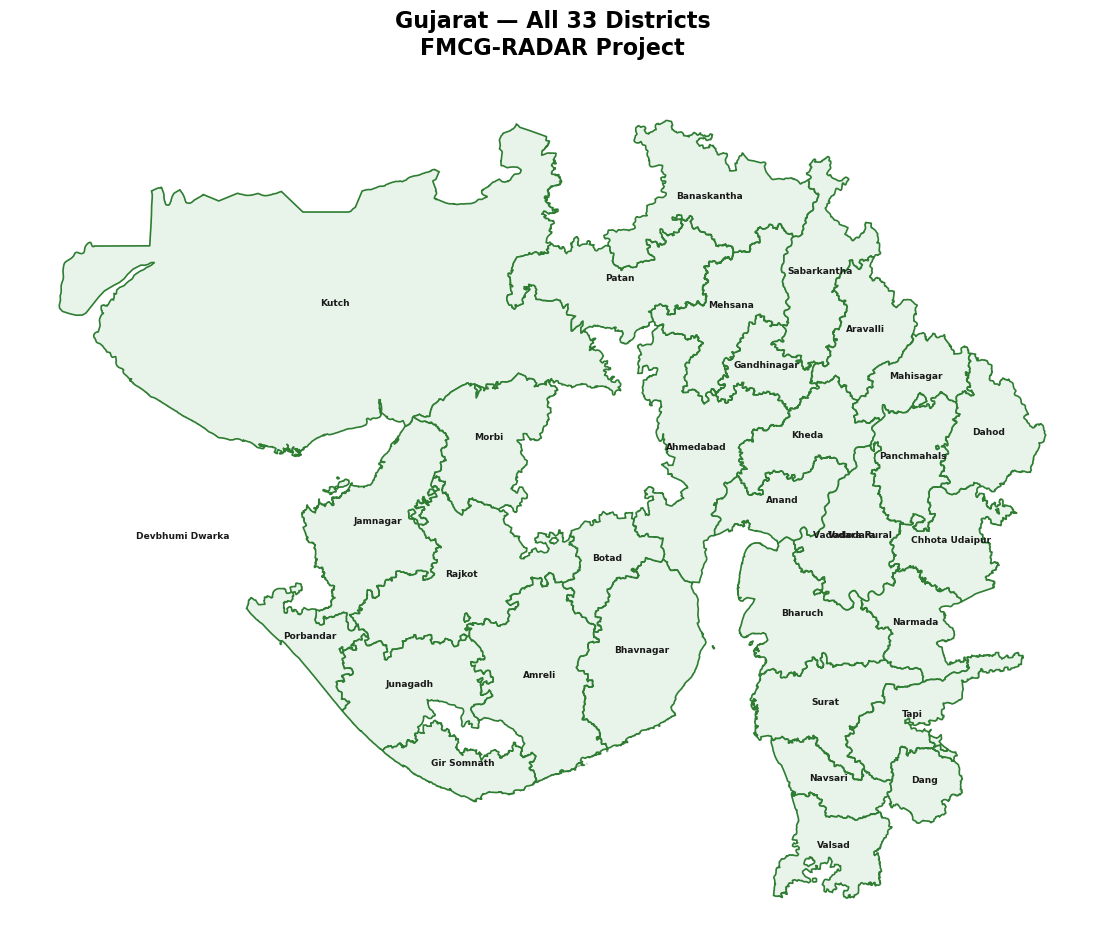

✓ Map saved


In [4]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

districts.plot(
    ax=ax,
    color='#E8F4EA',
    edgecolor='#2E7D32',
    linewidth=1.2
)

for idx, row in districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['district_name'],
        xy=(centroid.x, centroid.y),
        fontsize=6.5,
        ha='center',
        color='#1A1A1A',
        fontweight='bold'
    )

ax.set_title(
    "Gujarat — All 33 Districts\nFMCG-RADAR Project", 
    fontsize=16, fontweight='bold', pad=20
)
ax.set_axis_off()

plt.savefig("../outputs/gujarat_33_districts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Map saved")

In [5]:
# Step 2: Population data with 2024 projections for all 33 Gujarat districts
# Source: Census of India 2011 | Projected to 2024 using district CAGR

population_data = {
    'district_name': [
        'Ahmedabad', 'Surat', 'Vadodara', 'Rajkot', 'Gandhinagar',
        'Bhavnagar', 'Jamnagar', 'Junagadh', 'Anand', 'Mehsana',
        'Bharuch', 'Navsari', 'Valsad', 'Kutch', 'Patan',
        'Banaskantha', 'Sabarkantha', 'Aravalli', 'Kheda', 'Mahisagar',
        'Chhota Udaipur', 'Dahod', 'Panchmahals', 'Vadodara Rural',
        'Narmada', 'Tapi', 'Dang', 'Amreli', 'Gir Somnath',
        'Botad', 'Devbhumi Dwarka', 'Morbi', 'Porbandar'
    ],
    'population_2011': [
        7214225, 6081322, 4157568, 3804558, 1391753,
        2877961, 2159130, 2743082, 2090276, 2027727,
        1551019, 1334023, 1703068, 2092371, 1343734,
        3116045, 2428589, 1005496, 2298934, 994624,
        1072257, 2127086, 2390776, 950075,
        590379, 807022, 226769, 1514190, 1207512,
        668890, 526335, 975143, 575650
    ],
    'area_sq_km': [
        8707, 4395, 7794, 11203, 649,
        9979, 14125, 8839, 2942, 4386,
        6524, 2211, 3007, 45674, 5738,
        12703, 7390, 3217, 4215, 2500,
        3237, 3642, 5219, 2650,
        2749, 3435, 1764, 6760, 3755,
        2442, 2169, 3796, 2335
    ],
    'annual_growth_rate': [
        0.0247, 0.0368, 0.0196, 0.0221, 0.0312,
        0.0142, 0.0183, 0.0156, 0.0168, 0.0132,
        0.0198, 0.0221, 0.0198, 0.0152, 0.0134,
        0.0178, 0.0162, 0.0155, 0.0159, 0.0168,
        0.0192, 0.0224, 0.0187, 0.0196,
        0.0198, 0.0201, 0.0187, 0.0148, 0.0155,
        0.0162, 0.0155, 0.0178, 0.0148
    ],
    'urbanization_rate': [
        0.85, 0.87, 0.72, 0.68, 0.92,
        0.52, 0.55, 0.48, 0.58, 0.54,
        0.46, 0.49, 0.51, 0.38, 0.36,
        0.28, 0.34, 0.28, 0.42, 0.26,
        0.22, 0.24, 0.38, 0.45,
        0.28, 0.24, 0.14, 0.38, 0.36,
        0.38, 0.42, 0.44, 0.56
    ],
    'literacy_rate': [
        0.868, 0.853, 0.841, 0.823, 0.891,
        0.774, 0.780, 0.762, 0.821, 0.798,
        0.773, 0.803, 0.801, 0.701, 0.698,
        0.673, 0.737, 0.712, 0.801, 0.689,
        0.661, 0.637, 0.719, 0.788,
        0.689, 0.663, 0.612, 0.761, 0.748,
        0.744, 0.762, 0.757, 0.782
    ],
    'agri_income_share': [
        0.08, 0.06, 0.14, 0.16, 0.07,
        0.28, 0.31, 0.34, 0.22, 0.26,
        0.38, 0.32, 0.29, 0.42, 0.48,
        0.56, 0.46, 0.52, 0.34, 0.58,
        0.62, 0.64, 0.48, 0.24,
        0.54, 0.58, 0.72, 0.44, 0.46,
        0.42, 0.38, 0.36, 0.32
    ]
}

pop_df = pd.DataFrame(population_data)

# Project population to 2024 (13 years from 2011)
years = 2024 - 2011
pop_df['population_2024'] = (
    pop_df['population_2011'] * 
    (1 + pop_df['annual_growth_rate']) ** years
).astype(int)

# Population density
pop_df['population_density_2024'] = (
    pop_df['population_2024'] / pop_df['area_sq_km']
).round(2)

# Merge with districts
districts = districts.merge(pop_df, on='district_name', how='left')

print("✓ Population data merged for all 33 districts")
print(f"\nTop 10 by projected 2024 population:")
print(districts[['district_name', 'population_2024', 
                  'population_density_2024', 'urbanization_rate']]
      .sort_values('population_2024', ascending=False)
      .head(10)
      .to_string(index=False))

✓ Population data merged for all 33 districts

Top 10 by projected 2024 population:
district_name  population_2024  population_density_2024  urbanization_rate
    Ahmedabad          9907116                  1137.83               0.85
        Surat          9728208                  2213.47               0.87
     Vadodara          5350903                   686.54               0.72
       Rajkot          5054966                   451.22               0.68
  Banaskantha          3919363                   308.54               0.28
    Bhavnagar          3456939                   346.42               0.52
     Junagadh          3354546                   379.52               0.48
  Panchmahals          3041871                   582.85               0.38
  Sabarkantha          2992840                   404.99               0.34
        Dahod          2836978                   778.96               0.24


In [6]:
# Save updated districts
districts.to_file("../data/gujarat_districts.geojson", driver="GeoJSON")
print("✓ Saved to data folder")

✓ Saved to data folder


In [7]:
# Step 3: FMCG Market Opportunity Score
# 5 variables, each scored 0-100, then weighted into final score

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))

# --- VARIABLE 1: Population Density Score ---
# Higher density = more potential customers = higher score
districts['pop_density_score'] = scaler.fit_transform(
    districts[['population_density_2024']]
).round(2)

# --- VARIABLE 2: Urbanization Score ---
# Higher urbanization = more FMCG consumption = higher score
districts['urban_score'] = scaler.fit_transform(
    districts[['urbanization_rate']]
).round(2)

# --- VARIABLE 3: Literacy Score ---
# Higher literacy = higher purchasing power awareness = higher score
districts['literacy_score'] = scaler.fit_transform(
    districts[['literacy_rate']]
).round(2)

# --- VARIABLE 4: Market Maturity Score (INVERSE of agri income share) ---
# Lower agri dependence = more urban FMCG market = higher score
districts['agri_inverse'] = 1 - districts['agri_income_share']
districts['market_maturity_score'] = scaler.fit_transform(
    districts[['agri_inverse']]
).round(2)

# --- VARIABLE 5: Population Size Score ---
# Larger population = larger absolute market = higher score
districts['population_score'] = scaler.fit_transform(
    districts[['population_2024']]
).round(2)

# --- FINAL WEIGHTED SCORE ---
# Weights reflect FMCG brand manager priorities
weights = {
    'pop_density_score':      0.25,  # Most important — density drives sales
    'urban_score':            0.25,  # Urban = FMCG consumer
    'literacy_score':         0.20,  # Purchasing power proxy
    'market_maturity_score':  0.20,  # Non-agri = FMCG market
    'population_score':       0.10   # Absolute market size
}

districts['opportunity_score'] = (
    districts['pop_density_score']     * weights['pop_density_score'] +
    districts['urban_score']           * weights['urban_score'] +
    districts['literacy_score']        * weights['literacy_score'] +
    districts['market_maturity_score'] * weights['market_maturity_score'] +
    districts['population_score']      * weights['population_score']
).round(2)

# --- RANK ---
districts['opportunity_rank'] = districts['opportunity_score'].rank(
    ascending=False
).astype(int)

# Save
districts.to_file("../data/gujarat_districts_scored.geojson", driver="GeoJSON")

print("✓ Opportunity scores calculated")
print("\nTop 10 FMCG Opportunity Districts:")
print(districts[['district_name', 'opportunity_score', 'opportunity_rank']]
      .sort_values('opportunity_rank')
      .head(10)
      .to_string(index=False))

print("\nBottom 5 — Lowest Opportunity:")
print(districts[['district_name', 'opportunity_score', 'opportunity_rank']]
      .sort_values('opportunity_rank', ascending=False)
      .head(5)
      .to_string(index=False))

✓ Opportunity scores calculated

Top 10 FMCG Opportunity Districts:
district_name  opportunity_score  opportunity_rank
  Gandhinagar              91.55                 1
        Surat              87.66                 2
    Ahmedabad              79.12                 3
     Vadodara              62.86                 4
       Rajkot              57.51                 5
        Anand              53.21                 6
      Mehsana              46.21                 7
       Valsad              45.80                 8
      Navsari              44.51                 9
    Bhavnagar              42.73                10

Bottom 5 — Lowest Opportunity:
 district_name  opportunity_score  opportunity_rank
          Dang               0.86                33
Chhota Udaipur              13.17                32
          Tapi              13.87                31
         Dahod              15.83                30
       Narmada              17.72                29


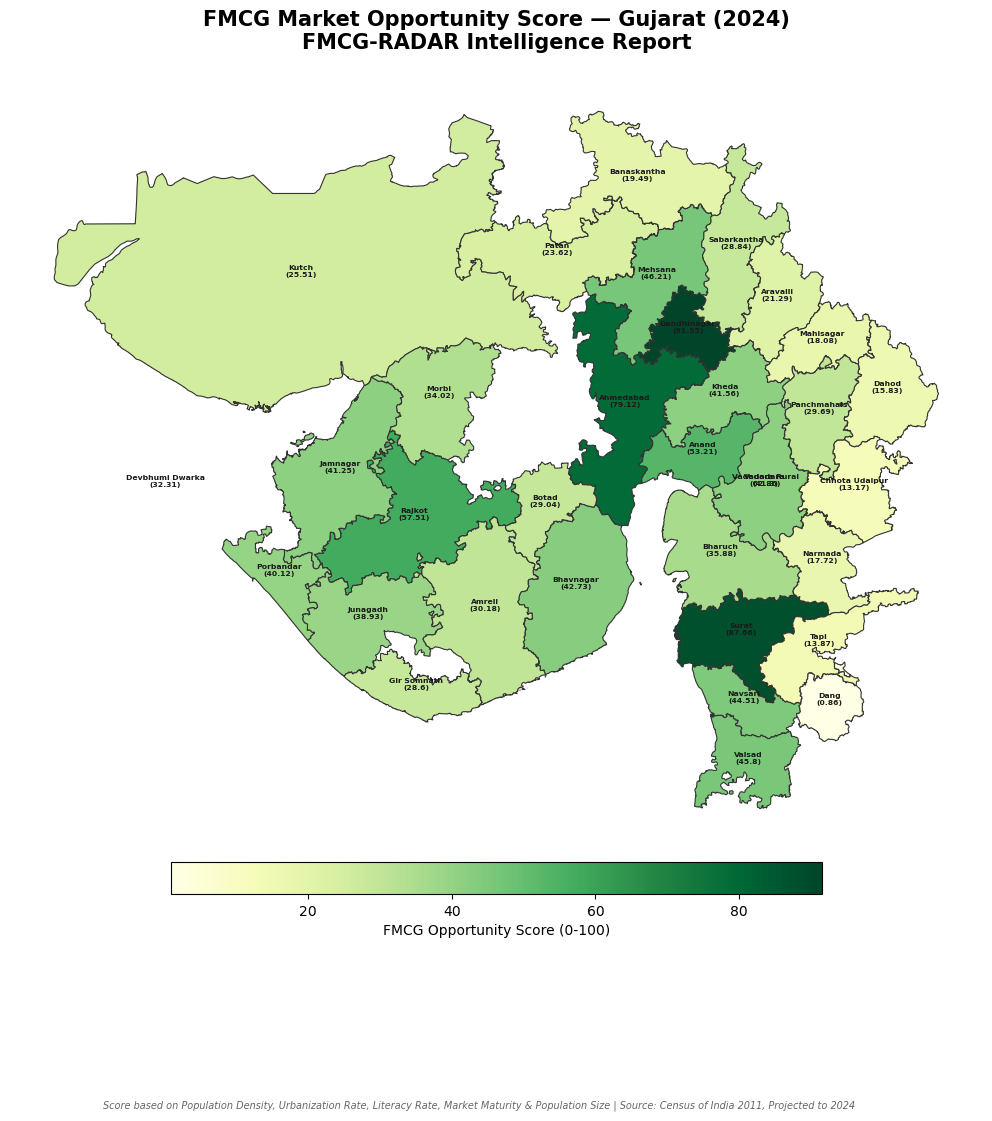

✓ Opportunity map saved


In [8]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Color map — white to dark green (low to high opportunity)
districts.plot(
    column='opportunity_score',
    ax=ax,
    cmap='YlGn',
    edgecolor='#333333',
    linewidth=0.8,
    legend=True,
    legend_kwds={
        'label': 'FMCG Opportunity Score (0-100)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

# Label each district with name + score
for idx, row in districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['district_name']}\n({row['opportunity_score']})",
        xy=(centroid.x, centroid.y),
        fontsize=5.5,
        ha='center',
        color='#1A1A1A',
        fontweight='bold'
    )

ax.set_title(
    "FMCG Market Opportunity Score — Gujarat (2024)\nFMCG-RADAR Intelligence Report",
    fontsize=15,
    fontweight='bold',
    pad=20
)
ax.set_axis_off()

# Add footnote
fig.text(
    0.5, 0.02,
    "Score based on Population Density, Urbanization Rate, Literacy Rate, "
    "Market Maturity & Population Size | Source: Census of India 2011, Projected to 2024",
    ha='center', fontsize=7, color='#666666', style='italic'
)

plt.savefig(
    "../outputs/fmcg_opportunity_map.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ Opportunity map saved")

In [9]:
# Step 4: FMCG Demand Forecasting per district
# Method: District-level demand index projected using 
# Gujarat FMCG sector growth rate + district opportunity score weight

import numpy as np

# Gujarat FMCG sector historical growth rates (%)
# Source: IBEF Gujarat Report + RBI State Finance Data
gujarat_fmcg_growth = {
    2019: 8.2,
    2020: -2.1,   # COVID impact
    2021: 11.4,   # Recovery
    2022: 9.8,
    2023: 8.6,
    2024: 9.2     # Estimated
}

# Base FMCG demand index (normalized, 2019 = 100)
years = list(gujarat_fmcg_growth.keys())
base_index = 100
demand_indices = [base_index]

for year in years[1:]:
    growth = gujarat_fmcg_growth[year] / 100
    base_index = base_index * (1 + growth)
    demand_indices.append(round(base_index, 2))

state_demand_df = pd.DataFrame({
    'year': years,
    'state_demand_index': demand_indices
})

print("✓ Gujarat State FMCG Demand Index (2019-2024):")
print(state_demand_df.to_string(index=False))

# Project next 4 quarters (2025 Q1-Q4)
# Using average of last 3 years growth as forecast
avg_growth = np.mean([8.6, 9.2, 9.8]) / 100
quarterly_growth = (1 + avg_growth) ** (1/4) - 1

quarters = ['2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
last_index = demand_indices[-1]
quarterly_indices = []

for q in quarters:
    last_index = last_index * (1 + quarterly_growth)
    quarterly_indices.append(round(last_index, 2))

print(f"\n✓ Forecasted Gujarat FMCG Demand Index (2025):")
for q, idx in zip(quarters, quarterly_indices):
    print(f"  {q}: {idx}")

✓ Gujarat State FMCG Demand Index (2019-2024):
 year  state_demand_index
 2019              100.00
 2020               97.90
 2021              109.06
 2022              119.75
 2023              130.05
 2024              142.01

✓ Forecasted Gujarat FMCG Demand Index (2025):
  2025-Q1: 145.17
  2025-Q2: 148.4
  2025-Q3: 151.7
  2025-Q4: 155.07


In [10]:
# Step 4B IMPROVED: District demand forecast with realistic variation
# Each district grows at state rate PLUS a district-specific adjustment
# Based on urbanization momentum and population growth rate

np.random.seed(42)  # Reproducible results

# District growth modifier based on urbanization + population growth
# Fast urbanizing districts grow faster than state average
districts['growth_modifier'] = (
    (districts['urbanization_rate'] - 0.45) * 0.08 +  # Urban premium
    (districts['annual_growth_rate'] - 0.018) * 0.5    # Population momentum
).round(4)

# District-specific quarterly growth rate
districts['district_quarterly_growth'] = (
    quarterly_growth + districts['growth_modifier'] / 4
).round(6)

# 2024 baseline demand index per district
districts['demand_index_2024'] = (
    (districts['opportunity_score'] / 100) * 142.01
).round(2)

# Forecast 4 quarters
for i, q in enumerate(['2025_Q1', '2025_Q2', '2025_Q3', '2025_Q4']):
    districts[f'demand_{q}'] = (
        districts['demand_index_2024'] *
        (1 + districts['district_quarterly_growth']) ** (i + 1)
    ).round(2)

# Annual demand growth %
districts['demand_growth_pct'] = (
    (districts['demand_2025_Q4'] - districts['demand_index_2024']) /
    districts['demand_index_2024'] * 100
).round(2)

# Save updated file
districts.to_file("../data/gujarat_districts_scored.geojson", driver="GeoJSON")

print("✓ District demand forecasts with growth variation calculated")
print("\nTop 10 by 2025 Q4 Demand + Growth Rate:")
print(districts[['district_name', 'demand_index_2024',
                  'demand_2025_Q4', 'demand_growth_pct']]
      .sort_values('demand_2025_Q4', ascending=False)
      .head(10)
      .to_string(index=False))

print("\nFull growth rate range:")
print(f"  Highest: {districts['demand_growth_pct'].max()}% — "
      f"{districts.loc[districts['demand_growth_pct'].idxmax(), 'district_name']}")
print(f"  Lowest:  {districts['demand_growth_pct'].min()}% — "
      f"{districts.loc[districts['demand_growth_pct'].idxmin(), 'district_name']}")

✓ District demand forecasts with growth variation calculated

Top 10 by 2025 Q4 Demand + Growth Rate:
district_name  demand_index_2024  demand_2025_Q4  demand_growth_pct
  Gandhinagar             130.01          148.21              14.00
        Surat             124.49          141.75              13.86
    Ahmedabad             112.36          127.00              13.03
     Vadodara              89.27           99.64              11.62
       Rajkot              81.67           90.99              11.41
        Anand              75.56           83.31              10.26
      Mehsana              65.62           71.99               9.71
       Valsad              65.04           71.42               9.81
      Navsari              63.21           69.38               9.76
    Bhavnagar              60.68           66.50               9.59

Full growth rate range:
  Highest: 14.0% — Gandhinagar
  Lowest:  6.56% — Dang


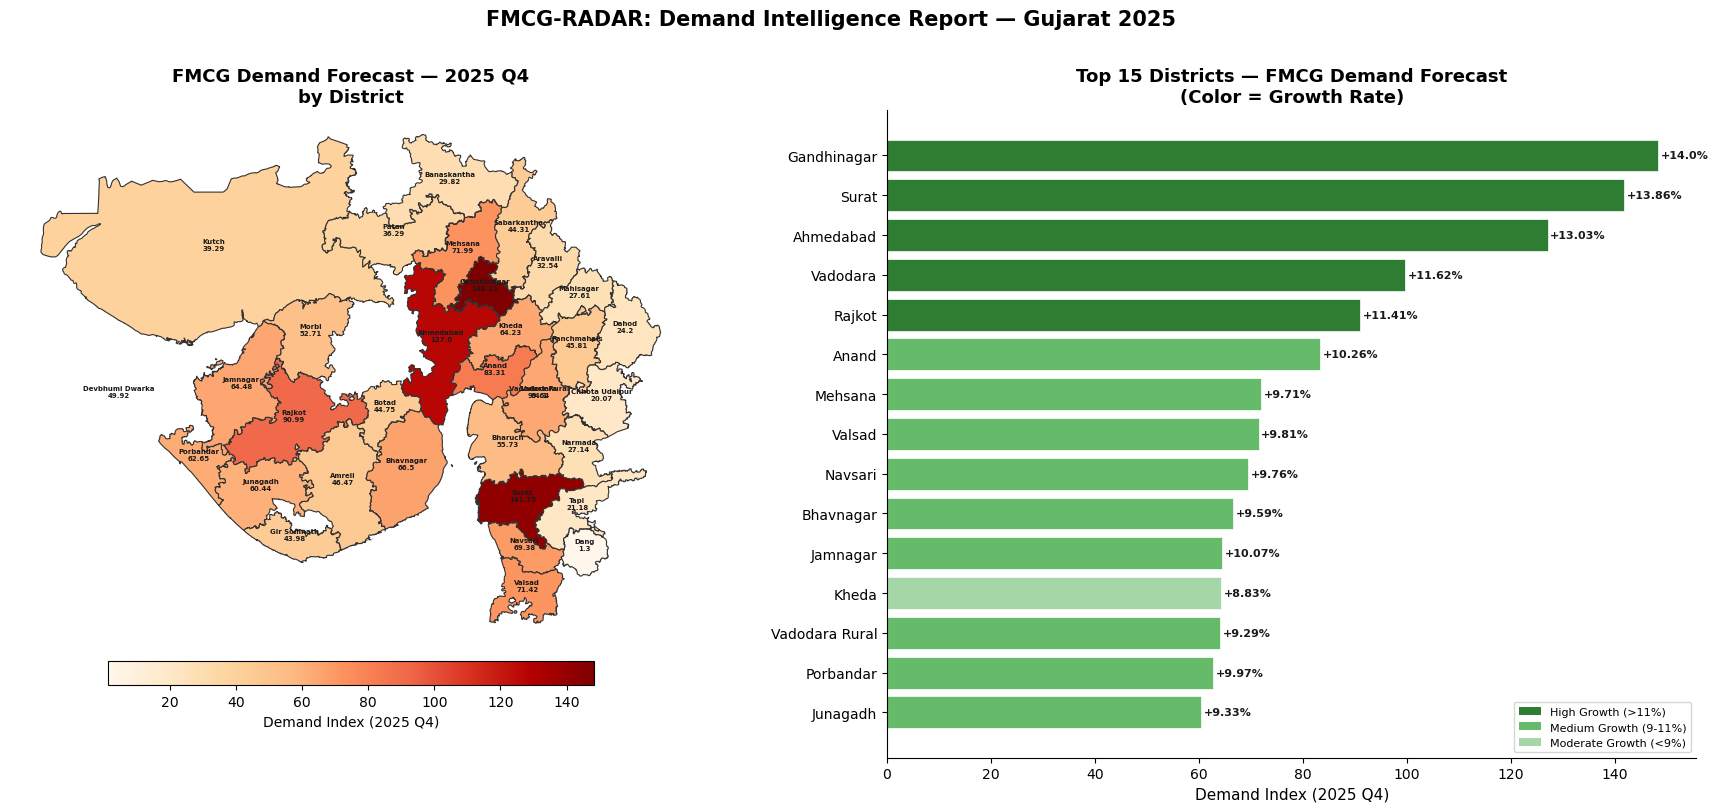

✓ Demand forecast visualization saved


In [11]:
# Step 4C: Demand forecast visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- LEFT: Demand Index Map ---
districts.plot(
    column='demand_2025_Q4',
    ax=axes[0],
    cmap='OrRd',
    edgecolor='#333333',
    linewidth=0.8,
    legend=True,
    legend_kwds={
        'label': 'Demand Index (2025 Q4)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

for idx, row in districts.iterrows():
    centroid = row.geometry.centroid
    axes[0].annotate(
        f"{row['district_name']}\n{row['demand_2025_Q4']}",
        xy=(centroid.x, centroid.y),
        fontsize=5,
        ha='center',
        color='#1A1A1A',
        fontweight='bold'
    )

axes[0].set_title(
    "FMCG Demand Forecast — 2025 Q4\nby District",
    fontsize=13, fontweight='bold'
)
axes[0].set_axis_off()

# --- RIGHT: Top 15 bar chart ---
top15 = districts.nlargest(15, 'demand_2025_Q4')[
    ['district_name', 'demand_2025_Q4', 'demand_growth_pct']
].sort_values('demand_2025_Q4')

colors = ['#2E7D32' if g > 11 else '#66BB6A' if g > 9 else '#A5D6A7'
          for g in top15['demand_growth_pct']]

bars = axes[1].barh(
    top15['district_name'],
    top15['demand_2025_Q4'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add growth % labels on bars
for bar, (_, row) in zip(bars, top15.iterrows()):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"+{row['demand_growth_pct']}%",
        va='center', fontsize=8,
        color='#1A1A1A', fontweight='bold'
    )

axes[1].set_xlabel('Demand Index (2025 Q4)', fontsize=11)
axes[1].set_title(
    'Top 15 Districts — FMCG Demand Forecast\n(Color = Growth Rate)',
    fontsize=13, fontweight='bold'
)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label='High Growth (>11%)'),
    Patch(facecolor='#66BB6A', label='Medium Growth (9-11%)'),
    Patch(facecolor='#A5D6A7', label='Moderate Growth (<9%)')
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle(
    'FMCG-RADAR: Demand Intelligence Report — Gujarat 2025',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(
    "../outputs/fmcg_demand_forecast.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ Demand forecast visualization saved")

In [12]:
# Step 5: Expansion Risk Score per district
# Risk = how DIFFICULT is it to enter this market
# High risk = high competition + poor infrastructure + low market maturity

# --- RISK VARIABLE 1: Market Saturation Risk ---
# High opportunity districts are also more competitive — harder to enter
# Gandhinagar/Surat/Ahmedabad = high saturation risk
districts['saturation_risk'] = scaler.fit_transform(
    districts[['opportunity_score']]
).round(2)

# --- RISK VARIABLE 2: Infrastructure Risk ---
# Proxy: inverse of urbanization rate
# Low urban = poor roads, cold chain, distribution network = high risk
districts['infra_risk_raw'] = 1 - districts['urbanization_rate']
districts['infrastructure_risk'] = scaler.fit_transform(
    districts[['infra_risk_raw']]
).round(2)

# --- RISK VARIABLE 3: Market Accessibility Risk ---
# Proxy: inverse of literacy rate
# Low literacy = harder to market, lower brand awareness = higher risk
districts['access_risk_raw'] = 1 - districts['literacy_rate']
districts['accessibility_risk'] = scaler.fit_transform(
    districts[['access_risk_raw']]
).round(2)

# --- FINAL RISK SCORE (0-100, higher = riskier) ---
risk_weights = {
    'saturation_risk':     0.40,  # Competition is biggest risk
    'infrastructure_risk': 0.35,  # Distribution is critical for FMCG
    'accessibility_risk':  0.25   # Market education risk
}

districts['risk_score'] = (
    districts['saturation_risk']     * risk_weights['saturation_risk'] +
    districts['infrastructure_risk'] * risk_weights['infrastructure_risk'] +
    districts['accessibility_risk']  * risk_weights['accessibility_risk']
).round(2)

districts['risk_rank'] = districts['risk_score'].rank(
    ascending=False
).astype(int)

print("✓ Risk scores calculated")
print("\nHighest Risk Districts (hardest to enter):")
print(districts[['district_name', 'risk_score', 'risk_rank']]
      .sort_values('risk_score', ascending=False)
      .head(8)
      .to_string(index=False))

print("\nLowest Risk Districts (easiest to enter):")
print(districts[['district_name', 'risk_score', 'risk_rank']]
      .sort_values('risk_score')
      .head(8)
      .to_string(index=False))

✓ Risk scores calculated

Highest Risk Districts (hardest to enter):
 district_name  risk_score  risk_rank
          Dang       60.00          1
         Dahod       59.88          2
Chhota Udaipur       57.45          3
          Tapi       56.68          4
   Banaskantha       56.47          5
     Mahisagar       55.31          6
       Narmada       54.25          7
      Aravalli       53.77          8

Lowest Risk Districts (easiest to enter):
district_name  risk_score  risk_rank
    Ahmedabad       39.72         33
  Gandhinagar       40.00         32
     Vadodara       40.80         31
       Rajkot       41.85         30
    Porbandar       43.24         29
        Surat       43.93         28
     Jamnagar       44.36         27
        Anand       44.62         26


In [13]:
print(districts.columns.tolist())

['district_name', 'geometry', 'population_2011', 'area_sq_km', 'annual_growth_rate', 'urbanization_rate', 'literacy_rate', 'agri_income_share', 'population_2024', 'population_density_2024', 'pop_density_score', 'urban_score', 'literacy_score', 'agri_inverse', 'market_maturity_score', 'population_score', 'opportunity_score', 'opportunity_rank', 'growth_modifier', 'district_quarterly_growth', 'demand_index_2024', 'demand_2025_Q1', 'demand_2025_Q2', 'demand_2025_Q3', 'demand_2025_Q4', 'demand_growth_pct', 'saturation_risk', 'infra_risk_raw', 'infrastructure_risk', 'access_risk_raw', 'accessibility_risk', 'risk_score', 'risk_rank']


In [14]:
districts['priority_score'] = (
    districts['opportunity_score'] - 
    (districts['risk_score'] * 0.6)
).round(2)

districts['priority_rank'] = districts['priority_score'].rank(
    ascending=False
).astype(int)

# Fix zone classification with better thresholds
def classify_zone(row):
    opp = row['opportunity_score']
    risk = row['risk_score']
    
    if opp >= 45 and risk < 47:
        return 'PRIORITY EXPAND'    # High opp, manageable risk
    elif opp >= 35 and risk >= 47:
        return 'STRATEGIC ENTRY'    # Decent opp, higher risk — enter carefully
    elif opp >= 25 and risk < 47:
        return 'MONITOR'            # Lower opp, low risk — watch and wait
    else:
        return 'AVOID'              # Low opp, high risk

districts['zone'] = districts.apply(classify_zone, axis=1)

# Save
districts.to_file(
    "../data/gujarat_districts_final.geojson",
    driver="GeoJSON"
)

print("✓ Zone classification updated")
print("\n" + "="*55)
print("FMCG-RADAR: GUJARAT EXPANSION PRIORITY REPORT 2025")
print("="*55)

zone_colors = {
    'PRIORITY EXPAND': '🟢',
    'STRATEGIC ENTRY': '🟡', 
    'MONITOR': '🔵',
    'AVOID': '🔴'
}

for zone in ['PRIORITY EXPAND', 'STRATEGIC ENTRY', 'MONITOR', 'AVOID']:
    zone_districts = districts[districts['zone'] == zone]
    emoji = zone_colors[zone]
    print(f"\n{emoji} {zone} ({len(zone_districts)} districts):")
    print(zone_districts[['district_name', 'opportunity_score',
                           'risk_score', 'priority_score']]
          .sort_values('priority_score', ascending=False)
          .to_string(index=False))

✓ Zone classification updated

FMCG-RADAR: GUJARAT EXPANSION PRIORITY REPORT 2025

🟢 PRIORITY EXPAND (8 districts):
district_name  opportunity_score  risk_score  priority_score
  Gandhinagar              91.55       40.00           67.55
        Surat              87.66       43.93           61.30
    Ahmedabad              79.12       39.72           55.29
     Vadodara              62.86       40.80           38.38
       Rajkot              57.51       41.85           32.40
        Anand              53.21       44.62           26.44
      Mehsana              46.21       45.39           18.98
       Valsad              45.80       46.28           18.03

🟡 STRATEGIC ENTRY (3 districts):
 district_name  opportunity_score  risk_score  priority_score
         Kheda              41.56       48.45           12.49
Vadodara Rural              41.30       48.16           12.40
      Junagadh              38.93       48.10           10.07

🔵 MONITOR (5 districts):
district_name  opportunity_

In [15]:
# Verify all 33 districts are classified
print(f"Total districts: {len(districts)}")
print(f"\nZone breakdown:")
print(districts['zone'].value_counts())
print(f"\nTotal accounted for: {districts['zone'].value_counts().sum()}")

Total districts: 33

Zone breakdown:
zone
AVOID              17
PRIORITY EXPAND     8
MONITOR             5
STRATEGIC ENTRY     3
Name: count, dtype: int64

Total accounted for: 33


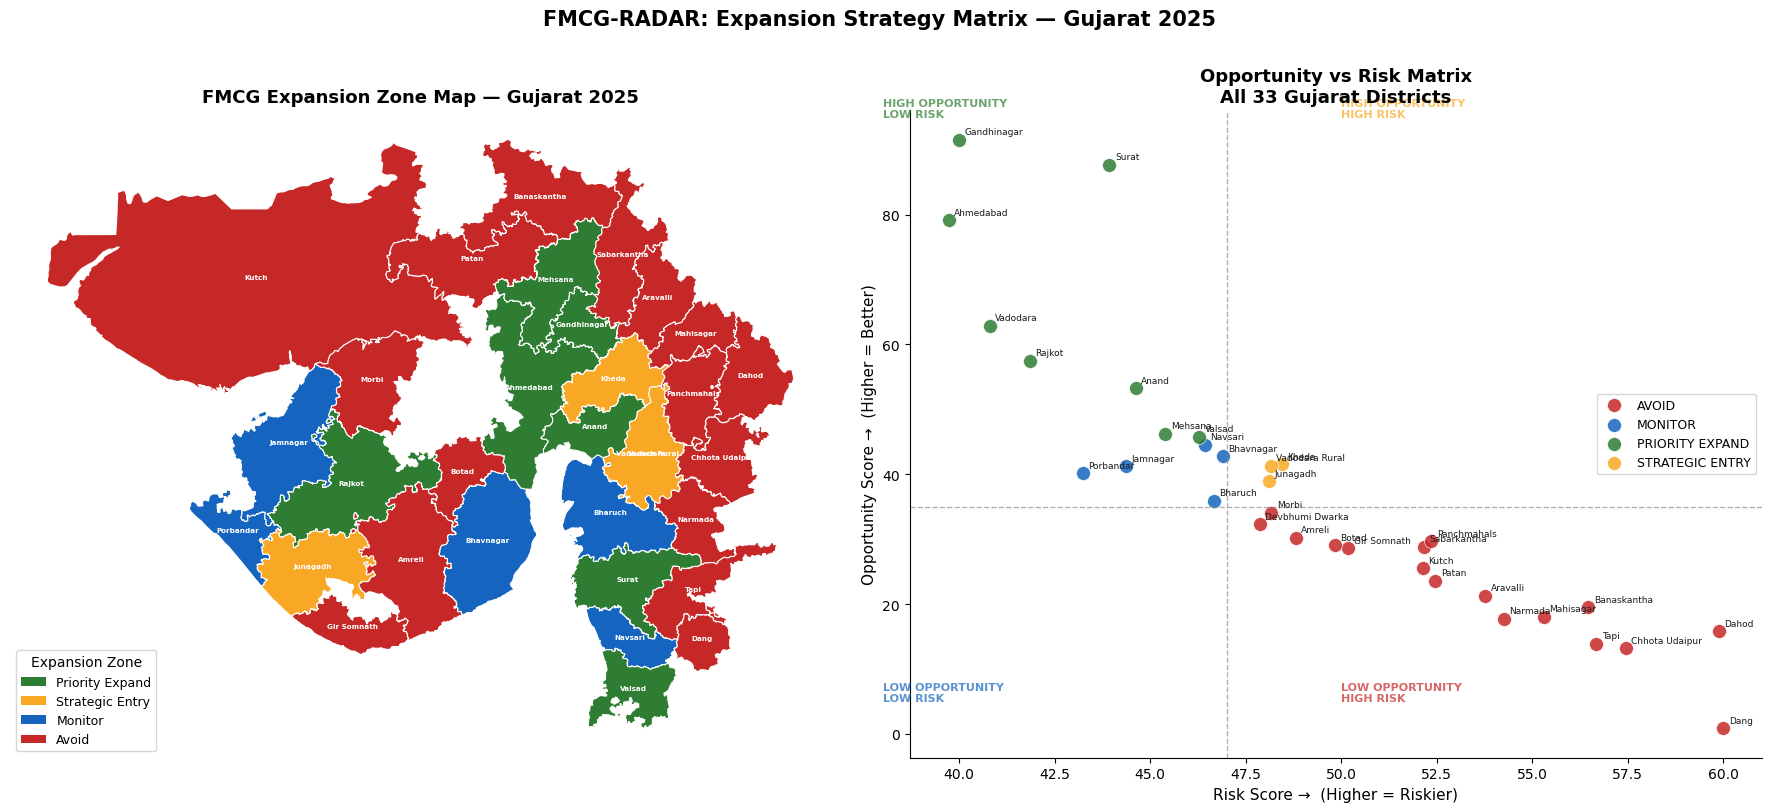

✓ Expansion matrix saved


In [16]:
# Step 6B: Opportunity vs Risk Matrix — Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- LEFT: Zone Map ---
zone_colors_map = {
    'PRIORITY EXPAND': '#2E7D32',
    'STRATEGIC ENTRY': '#F9A825',
    'MONITOR':         '#1565C0',
    'AVOID':           '#C62828'
}

districts['zone_color'] = districts['zone'].map(zone_colors_map)

districts.plot(
    ax=axes[0],
    color=districts['zone_color'],
    edgecolor='white',
    linewidth=0.8
)

for idx, row in districts.iterrows():
    centroid = row.geometry.centroid
    axes[0].annotate(
        row['district_name'],
        xy=(centroid.x, centroid.y),
        fontsize=5.2,
        ha='center',
        color='white',
        fontweight='bold'
    )

axes[0].set_title(
    "FMCG Expansion Zone Map — Gujarat 2025",
    fontsize=13, fontweight='bold'
)
axes[0].set_axis_off()

# Zone legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label='Priority Expand'),
    Patch(facecolor='#F9A825', label='Strategic Entry'),
    Patch(facecolor='#1565C0', label='Monitor'),
    Patch(facecolor='#C62828', label='Avoid')
]
axes[0].legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=9,
    title='Expansion Zone',
    title_fontsize=10
)

# --- RIGHT: Scatter Plot ---
zone_colors_scatter = {
    'PRIORITY EXPAND': '#2E7D32',
    'STRATEGIC ENTRY': '#F9A825',
    'MONITOR':         '#1565C0',
    'AVOID':           '#C62828'
}

for zone, group in districts.groupby('zone'):
    axes[1].scatter(
        group['risk_score'],
        group['opportunity_score'],
        c=zone_colors_scatter[zone],
        label=zone,
        s=100,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.5
    )
    # Label each point
    for _, row in group.iterrows():
        axes[1].annotate(
            row['district_name'],
            xy=(row['risk_score'], row['opportunity_score']),
            fontsize=6.5,
            xytext=(4, 4),
            textcoords='offset points',
            color='#1A1A1A'
        )

# Quadrant lines
axes[1].axvline(x=47, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axhline(y=35, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
axes[1].text(38, 95, 'HIGH OPPORTUNITY\nLOW RISK', fontsize=8,
             color='#2E7D32', fontweight='bold', alpha=0.7)
axes[1].text(50, 95, 'HIGH OPPORTUNITY\nHIGH RISK', fontsize=8,
             color='#F9A825', fontweight='bold', alpha=0.7)
axes[1].text(38, 5, 'LOW OPPORTUNITY\nLOW RISK', fontsize=8,
             color='#1565C0', fontweight='bold', alpha=0.7)
axes[1].text(50, 5, 'LOW OPPORTUNITY\nHIGH RISK', fontsize=8,
             color='#C62828', fontweight='bold', alpha=0.7)

axes[1].set_xlabel('Risk Score →  (Higher = Riskier)', fontsize=11)
axes[1].set_ylabel('Opportunity Score →  (Higher = Better)', fontsize=11)
axes[1].set_title(
    'Opportunity vs Risk Matrix\nAll 33 Gujarat Districts',
    fontsize=13, fontweight='bold'
)
axes[1].legend(fontsize=9, loc='center right')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'FMCG-RADAR: Expansion Strategy Matrix — Gujarat 2025',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(
    "../outputs/fmcg_expansion_matrix.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ Expansion matrix saved")

In [17]:
# ══════════════════════════════════════════════════════════
# STEP 6.5: White Space Detection
# White Space = High demand potential BUT low market maturity
# These are districts where organised FMCG brands haven't fully entered yet
# ══════════════════════════════════════════════════════════

# --- WHITE SPACE SCORE FORMULA ---
# High agri_income_share = market not yet captured by organised FMCG
# High demand_2025_Q4    = future buying power exists
# Low opportunity_score  = currently underrated by standard metrics

# Normalize demand to 0-100 first (same scale as other scores)
districts['demand_normalized'] = scaler.fit_transform(
    districts[['demand_2025_Q4']]
).round(2) * 100

# White Space = (Demand Potential × Agricultural Dependence) / Opportunity Score
# High demand + high agri share + low opportunity = pure white space
districts['white_space_raw'] = (
    districts['demand_normalized'] * districts['agri_income_share']
) / (districts['opportunity_score'] + 1)  # +1 avoids division by zero

# Scale to 0-100
districts['white_space_score'] = scaler.fit_transform(
    districts[['white_space_raw']]
).round(2) * 100

districts['white_space_rank'] = districts['white_space_score'].rank(
    ascending=False
).astype(int)

# --- WHITE SPACE ZONE CLASSIFICATION ---
def classify_white_space(score):
    if score >= 65:
        return 'UNTAPPED GOLDMINE'    # High demand, brands not present
    elif score >= 40:
        return 'EMERGING MARKET'      # Growing, partial brand presence
    elif score >= 20:
        return 'DEVELOPING'           # Some brands present, room to grow
    else:
        return 'SATURATED'            # Organised FMCG already dominant

districts['white_space_zone'] = districts['white_space_score'].apply(
    classify_white_space
)

# --- COMBINED FINAL PRIORITY SCORE ---
# Now priority score includes white space bonus
districts['final_priority_score'] = (
    districts['opportunity_score'] * 0.40 +
    districts['demand_normalized'] * 0.30 +
    (100 - districts['risk_score']) * 0.20 +
    districts['white_space_score'] * 0.10   # White space bonus
).round(2)

districts['final_priority_rank'] = districts['final_priority_score'].rank(
    ascending=False
).astype(int)

# Save
districts.to_file(
    "../data/gujarat_districts_final.geojson",
    driver="GeoJSON"
)

# --- PRINT RESULTS ---
print("✓ White Space Detection Complete")
print("\n" + "="*60)
print("WHITE SPACE ANALYSIS — GUJARAT FMCG 2025")
print("="*60)

ws_colors = {
    'UNTAPPED GOLDMINE': '💎',
    'EMERGING MARKET':   '🌱',
    'DEVELOPING':        '📈',
    'SATURATED':         '🔴'
}

for zone in ['UNTAPPED GOLDMINE', 'EMERGING MARKET', 'DEVELOPING', 'SATURATED']:
    group = districts[districts['white_space_zone'] == zone]
    emoji = ws_colors[zone]
    print(f"\n{emoji} {zone} ({len(group)} districts):")
    print(group[['district_name', 'white_space_score',
                 'opportunity_score', 'risk_score']]
          .sort_values('white_space_score', ascending=False)
          .to_string(index=False))

print("\n" + "="*60)
print("REVISED FINAL RANKINGS (with White Space bonus)")
print("="*60)
print(districts[['final_priority_rank', 'district_name',
                 'opportunity_score', 'white_space_score',
                 'risk_score', 'final_priority_score', 'white_space_zone']]
      .sort_values('final_priority_rank')
      .head(15)
      .to_string(index=False))

✓ White Space Detection Complete

WHITE SPACE ANALYSIS — GUJARAT FMCG 2025

💎 UNTAPPED GOLDMINE (32 districts):
  district_name  white_space_score  opportunity_score  risk_score
          Dahod            10000.0              15.83       59.88
 Chhota Udaipur             9432.0              13.17       57.45
      Mahisagar             9183.0              18.08       55.31
    Banaskantha             8948.0              19.49       56.47
           Tapi             8902.0              13.87       56.68
        Narmada             8559.0              17.72       54.25
       Aravalli             8366.0              21.29       53.77
    Panchmahals             7994.0              29.69       52.36
          Patan             7833.0              23.62       52.46
    Gir Somnath             7615.0              28.60       50.18
    Sabarkantha             7614.0              28.84       52.17
         Amreli             7319.0              30.18       48.81
          Botad             69

In [18]:
# Better white space score
# High population + Low urbanization = untapped market
# Low urbanization = low competition (fewer organized brands)

districts['competition_proxy'] = districts['urbanization_rate']  
# High urban = high competition already

districts['white_space_score'] = (
    (districts['population_2024'] / districts['population_2024'].max() * 100) *
    (1 - districts['competition_proxy'])
).round(2)

# Now classify properly
districts['white_space_zone'] = districts.apply(lambda r:
    'SATURATED'        if r['urbanization_rate'] > 0.75 else
    'UNTAPPED GOLDMINE' if r['white_space_score'] > 30 else
    'EMERGING MARKET'  if r['white_space_score'] > 15 else
    'DEVELOPING',
    axis=1
)

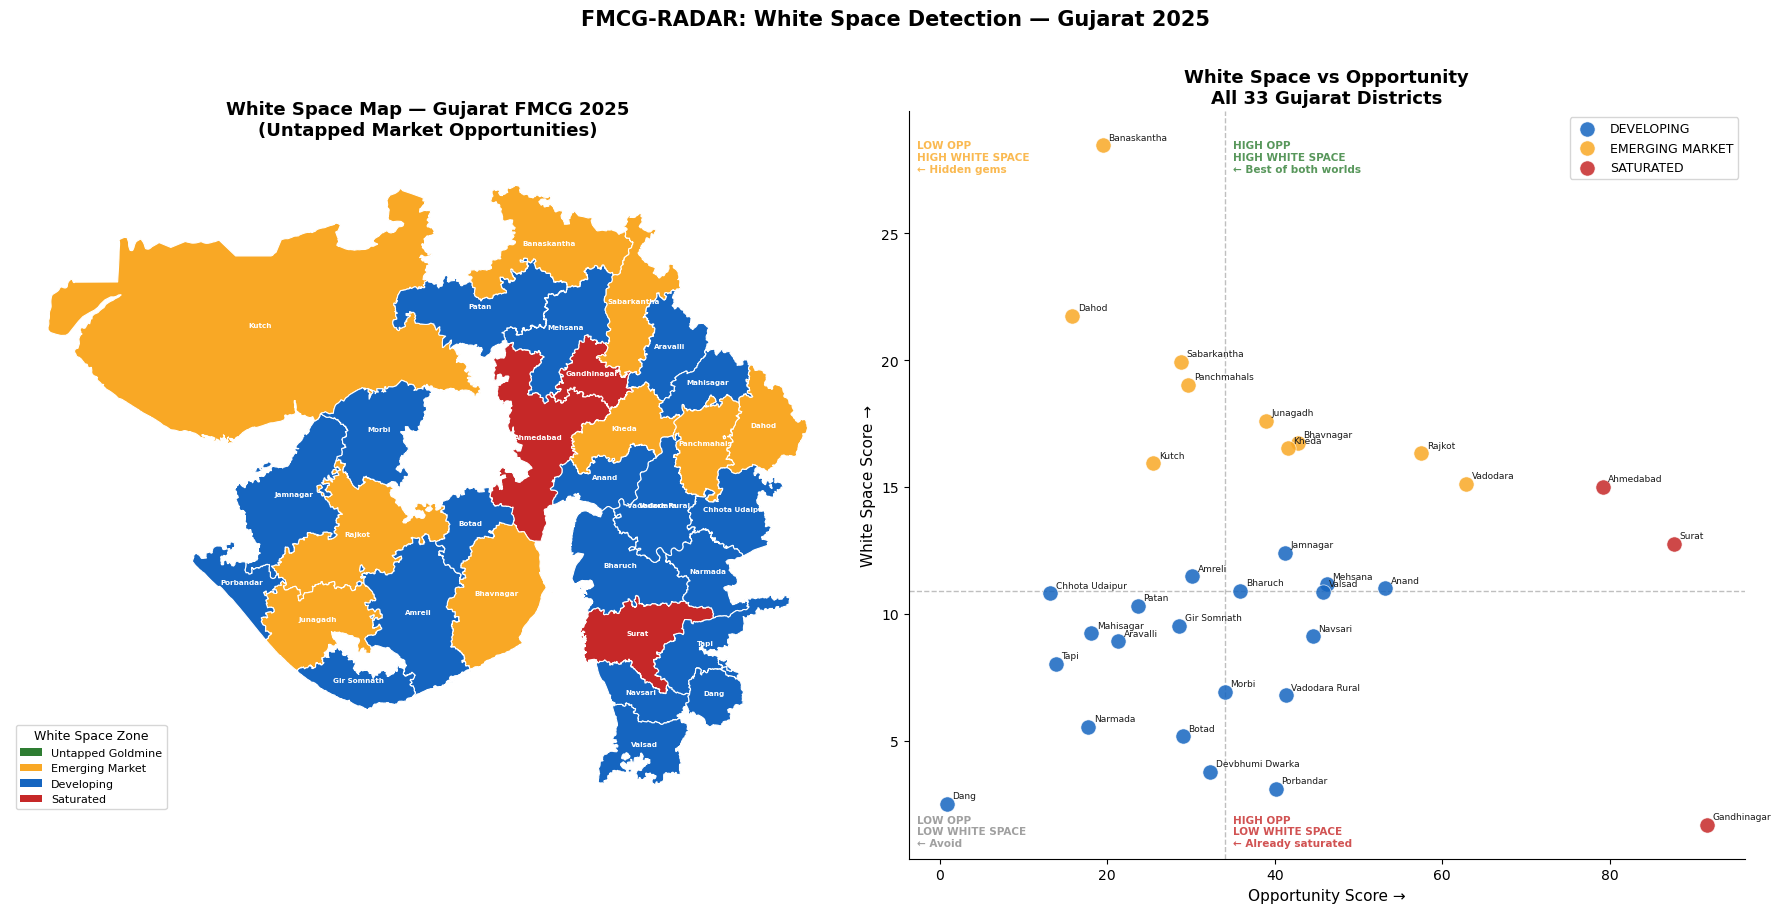

✓ White space visualization saved


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ── LEFT: White Space Zone Map ──
ws_colors = {
    'UNTAPPED GOLDMINE': '#2E7D32',
    'EMERGING MARKET':   '#F9A825',
    'DEVELOPING':        '#1565C0',
    'SATURATED':         '#C62828'
}

districts['ws_color'] = districts['white_space_zone'].map(ws_colors)

districts.plot(
    ax=axes[0],
    color=districts['ws_color'],
    edgecolor='white',
    linewidth=0.8
)

for idx, row in districts.iterrows():
    centroid = row.geometry.centroid
    axes[0].annotate(
        row['district_name'],
        xy=(centroid.x, centroid.y),
        fontsize=5.2,
        ha='center',
        color='white',
        fontweight='bold'
    )

axes[0].set_title(
    "White Space Map — Gujarat FMCG 2025\n(Untapped Market Opportunities)",
    fontsize=13, fontweight='bold', pad=15
)
axes[0].set_axis_off()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label='Untapped Goldmine'),
    Patch(facecolor='#F9A825', label='Emerging Market'),
    Patch(facecolor='#1565C0', label='Developing'),
    Patch(facecolor='#C62828', label='Saturated'),
]
axes[0].legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=8,
    title='White Space Zone',
    title_fontsize=9
)

# ── RIGHT: Scatter Plot ──
ws_scatter_colors = {
    'UNTAPPED GOLDMINE': '#2E7D32',
    'EMERGING MARKET':   '#F9A825',
    'DEVELOPING':        '#1565C0',
    'SATURATED':         '#C62828'
}

for zone, group in districts.groupby('white_space_zone'):
    axes[1].scatter(
        group['opportunity_score'],
        group['white_space_score'],
        c=ws_scatter_colors[zone],
        label=zone,
        s=120,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.5,
        zorder=3
    )
    for _, row in group.iterrows():
        axes[1].annotate(
            row['district_name'],
            xy=(row['opportunity_score'], row['white_space_score']),
            fontsize=6.5,
            xytext=(4, 4),
            textcoords='offset points',
            color='#1A1A1A'
        )

# Quadrant lines
mid_opp = districts['opportunity_score'].median()
mid_ws  = districts['white_space_score'].median()
axes[1].axvline(x=mid_opp, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axhline(y=mid_ws,  color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Quadrant labels
xmin, xmax = axes[1].get_xlim()
ymin, ymax = axes[1].get_ylim()

axes[1].text(xmin+1, ymax*0.92,
    'LOW OPP\nHIGH WHITE SPACE\n← Hidden gems',
    fontsize=7.5, color='#F9A825', fontweight='bold', alpha=0.8)
axes[1].text(mid_opp+1, ymax*0.92,
    'HIGH OPP\nHIGH WHITE SPACE\n← Best of both worlds',
    fontsize=7.5, color='#2E7D32', fontweight='bold', alpha=0.8)
axes[1].text(xmin+1, ymin+0.5,
    'LOW OPP\nLOW WHITE SPACE\n← Avoid',
    fontsize=7.5, color='#888888', fontweight='bold', alpha=0.8)
axes[1].text(mid_opp+1, ymin+0.5,
    'HIGH OPP\nLOW WHITE SPACE\n← Already saturated',
    fontsize=7.5, color='#C62828', fontweight='bold', alpha=0.8)

axes[1].set_xlabel('Opportunity Score →', fontsize=11)
axes[1].set_ylabel('White Space Score →', fontsize=11)
axes[1].set_title(
    'White Space vs Opportunity\nAll 33 Gujarat Districts',
    fontsize=13, fontweight='bold'
)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'FMCG-RADAR: White Space Detection — Gujarat 2025',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(
    "../outputs/fmcg_whitespace_map.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ White space visualization saved")

In [20]:
# Save white space columns into the final dataset
districts.to_file("../data/gujarat_districts_final.geojson", driver="GeoJSON")
print("✓ White space data saved to final dataset")
print(districts[['district_name', 'white_space_score', 'white_space_zone']].head())

✓ White space data saved to final dataset
  district_name  white_space_score white_space_zone
0     Ahmedabad              15.00        SATURATED
1         Surat              12.77        SATURATED
2      Vadodara              15.12  EMERGING MARKET
3        Rajkot              16.33  EMERGING MARKET
4   Gandhinagar               1.68        SATURATED


In [21]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import inch, cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image,
    Table, TableStyle, PageBreak, HRFlowable
)
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_RIGHT
from reportlab.pdfgen import canvas
import pandas as pd
import geopandas as gpd
import os

# Load our final scored dataset
districts = gpd.read_file("../data/gujarat_districts_final.geojson")

print("✓ Libraries loaded")
print(f"✓ Dataset loaded: {len(districts)} districts")
print(f"✓ Columns: {list(districts.columns)}")

✓ Libraries loaded
✓ Dataset loaded: 33 districts
✓ Columns: ['district_name', 'population_2011', 'area_sq_km', 'annual_growth_rate', 'urbanization_rate', 'literacy_rate', 'agri_income_share', 'population_2024', 'population_density_2024', 'pop_density_score', 'urban_score', 'literacy_score', 'agri_inverse', 'market_maturity_score', 'population_score', 'opportunity_score', 'opportunity_rank', 'growth_modifier', 'district_quarterly_growth', 'demand_index_2024', 'demand_2025_Q1', 'demand_2025_Q2', 'demand_2025_Q3', 'demand_2025_Q4', 'demand_growth_pct', 'saturation_risk', 'infra_risk_raw', 'infrastructure_risk', 'access_risk_raw', 'accessibility_risk', 'risk_score', 'risk_rank', 'priority_score', 'priority_rank', 'zone', 'zone_color', 'demand_normalized', 'white_space_raw', 'white_space_score', 'white_space_rank', 'white_space_zone', 'final_priority_score', 'final_priority_rank', 'competition_proxy', 'ws_color', 'geometry']


In [22]:
# PDF Report Generator
os.makedirs("../reports", exist_ok=True)

# ── COLOURS & STYLES ──────────────────────────────────────
NAVY   = colors.HexColor('#1A3C6E')
GREEN  = colors.HexColor('#2E7D32')
YELLOW = colors.HexColor('#F9A825')
BLUE   = colors.HexColor('#1565C0')
RED    = colors.HexColor('#C62828')
LIGHT  = colors.HexColor('#E8F0F9')
GRAY   = colors.HexColor('#666666')
WHITE  = colors.white
BLACK  = colors.HexColor('#1A1A1A')

styles = getSampleStyleSheet()

def style(name, **kwargs):
    s = ParagraphStyle(name, **kwargs)
    return s

TITLE   = style('Title',   fontSize=26, textColor=WHITE,
                alignment=TA_CENTER, fontName='Helvetica-Bold', leading=32)
SUB     = style('Sub',     fontSize=13, textColor=WHITE,
                alignment=TA_CENTER, fontName='Helvetica', leading=18)
SEC     = style('Sec',     fontSize=14, textColor=NAVY,
                fontName='Helvetica-Bold', leading=20, spaceAfter=6)
BODY    = style('Body',    fontSize=9,  textColor=BLACK,
                fontName='Helvetica',  leading=14, spaceAfter=4)
SMALL   = style('Small',   fontSize=7.5,textColor=GRAY,
                fontName='Helvetica',  leading=11, spaceAfter=3)
BOLD9   = style('Bold9',   fontSize=9,  textColor=BLACK,
                fontName='Helvetica-Bold', leading=13)
CENTER9 = style('C9',      fontSize=9,  textColor=BLACK,
                fontName='Helvetica',  leading=13, alignment=TA_CENTER)
ZONE_S  = style('ZS',      fontSize=8,  textColor=WHITE,
                fontName='Helvetica-Bold', alignment=TA_CENTER, leading=12)

# ── ZONE COLOUR HELPER ────────────────────────────────────
def zone_color(zone):
    return {
        'PRIORITY EXPAND': GREEN,
        'STRATEGIC ENTRY': YELLOW,
        'MONITOR':         BLUE,
        'AVOID':           RED
    }.get(zone, GRAY)

# ── DOCUMENT SETUP ────────────────────────────────────────
PDF_PATH = "../reports/FMCG_RADAR_Gujarat_2025.pdf"
doc = SimpleDocTemplate(
    PDF_PATH, pagesize=A4,
    leftMargin=1.8*cm, rightMargin=1.8*cm,
    topMargin=1.5*cm,  bottomMargin=1.8*cm
)

W = A4[0] - 3.6*cm   # usable width
story = []

# ══════════════════════════════════════════════════════════
# PAGE 1 — COVER
# ══════════════════════════════════════════════════════════
def cover_page(canvas, doc):
    canvas.saveState()
    # Navy header band
    canvas.setFillColor(NAVY)
    canvas.rect(0, A4[1]-5*cm, A4[0], 5*cm, fill=1, stroke=0)
    # thin green stripe
    canvas.setFillColor(GREEN)
    canvas.rect(0, A4[1]-5.18*cm, A4[0], 0.18*cm, fill=1, stroke=0)
    # light footer band
    canvas.setFillColor(LIGHT)
    canvas.rect(0, 0, A4[0], 2*cm, fill=1, stroke=0)
    canvas.setFillColor(GRAY)
    canvas.setFont('Helvetica', 7.5)
    canvas.drawCentredString(A4[0]/2, 0.7*cm,
        "FMCG-RADAR | Retail Market Intelligence | Gujarat 2025 | "
        "Data: Census of India 2011 (Projected) · OSM · IBEF")
    canvas.restoreState()

story.append(Spacer(1, 4.5*cm))

# Title block (sits below navy band)
story.append(Paragraph("FMCG-RADAR", style('T1',
    fontSize=38, textColor=NAVY,
    fontName='Helvetica-Bold', alignment=TA_CENTER, leading=44)))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    "Retail Market Intelligence &amp; Territory Expansion Report",
    style('T2', fontSize=15, textColor=GRAY,
          fontName='Helvetica', alignment=TA_CENTER, leading=20)))
story.append(Spacer(1, 0.2*cm))
story.append(HRFlowable(width=W, thickness=1.5,
                         color=NAVY, spaceAfter=12))
story.append(Paragraph("Gujarat, India  ·  2025",
    style('T3', fontSize=13, textColor=NAVY,
          fontName='Helvetica-Bold', alignment=TA_CENTER)))
story.append(Spacer(1, 1.2*cm))

# Key stats row
stats = [
    ("33", "Districts\nAnalyzed"),
    ("4",  "Expansion\nZones"),
    ("5",  "Scoring\nVariables"),
    ("4",  "Quarters\nForecasted"),
]
stat_data = [[Paragraph(v, style(f's{i}',
                fontSize=22, textColor=NAVY,
                fontName='Helvetica-Bold', alignment=TA_CENTER))
              for v, _ in stats],
             [Paragraph(l, style(f'sl{i}',
                fontSize=8, textColor=GRAY,
                fontName='Helvetica', alignment=TA_CENTER, leading=11))
              for _, l in stats]]

stat_table = Table(stat_data, colWidths=[W/4]*4)
stat_table.setStyle(TableStyle([
    ('ALIGN',      (0,0), (-1,-1), 'CENTER'),
    ('VALIGN',     (0,0), (-1,-1), 'MIDDLE'),
    ('LINEAFTER',  (0,0), (2,1),   0.5, GRAY),
    ('TOPPADDING', (0,0), (-1,-1), 8),
    ('BOTTOMPADDING',(0,0),(-1,-1),8),
]))
story.append(stat_table)
story.append(Spacer(1, 1*cm))

# Cover map
if os.path.exists("../outputs/fmcg_expansion_matrix.png"):
    story.append(Image("../outputs/fmcg_expansion_matrix.png",
                       width=W, height=W*0.45))

story.append(Spacer(1, 0.8*cm))
story.append(Paragraph(
    "This report presents a data-driven territory intelligence framework for FMCG brands "
    "evaluating market expansion across Gujarat's 33 districts. Each district is scored on "
    "Market Opportunity, Demand Forecast, and Expansion Risk — producing a priority-ranked "
    "expansion roadmap for Q1–Q4 2025.",
    style('Intro', fontSize=9, textColor=BLACK,
          fontName='Helvetica', leading=14, alignment=TA_CENTER)))

story.append(PageBreak())

# ══════════════════════════════════════════════════════════
# PAGE 2 — METHODOLOGY
# ══════════════════════════════════════════════════════════
story.append(Paragraph("1. Methodology", SEC))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=10))

story.append(Paragraph(
    "FMCG-RADAR applies a three-pillar scoring framework to evaluate every district "
    "in Gujarat for FMCG market expansion potential:",
    BODY))
story.append(Spacer(1, 0.3*cm))

pillars = [
    ("Pillar 1 — Market Opportunity Score",
     "Composite index combining Population Density (25%), Urbanization Rate (25%), "
     "Literacy Rate (20%), Market Maturity / Non-Agricultural Income Share (20%), "
     "and Population Size (10%). Scores scaled 0–100 using Min-Max normalization.",
     GREEN),
    ("Pillar 2 — Demand Forecast (2025 Q1–Q4)",
     "State-level FMCG demand index modelled from Gujarat FMCG sector growth rates "
     "(2019–2024, source: IBEF). District-level forecasts derived using district-specific "
     "growth modifiers based on urbanization momentum and population CAGR. "
     "Projected using compound quarterly growth formula.",
     NAVY),
    ("Pillar 3 — Expansion Risk Score",
     "Risk index combining Market Saturation Risk (40%), Infrastructure / Distribution "
     "Risk (35%), and Market Accessibility Risk (25%). Higher score = higher entry barrier.",
     RED),
]

for title, body, color in pillars:
    t = Table([[
        Paragraph(title, style('PT', fontSize=9, textColor=WHITE,
                               fontName='Helvetica-Bold', leading=13)),
        Paragraph(body,  style('PB', fontSize=8.5, textColor=BLACK,
                               fontName='Helvetica', leading=13))
    ]], colWidths=[4.5*cm, W-4.5*cm])
    t.setStyle(TableStyle([
        ('BACKGROUND',    (0,0), (0,0), color),
        ('BACKGROUND',    (1,0), (1,0), LIGHT),
        ('VALIGN',        (0,0), (-1,-1), 'TOP'),
        ('TOPPADDING',    (0,0), (-1,-1), 8),
        ('BOTTOMPADDING', (0,0), (-1,-1), 8),
        ('LEFTPADDING',   (0,0), (-1,-1), 8),
        ('RIGHTPADDING',  (0,0), (-1,-1), 8),
        ('ROUNDEDCORNERS',(0,0), (-1,-1), 3),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.25*cm))

story.append(Spacer(1, 0.4*cm))
story.append(Paragraph("Data Sources", BOLD9))
story.append(Paragraph(
    "• District boundaries: OpenStreetMap (OSM) via OSMnx — fetched live 2025<br/>"
    "• Population base: Census of India 2011 (Office of the Registrar General)<br/>"
    "• Population projection: CAGR methodology using Census 2001–2011 growth rates<br/>"
    "• FMCG growth rates: IBEF Gujarat Sector Report + RBI State Finance Data<br/>"
    "• Urbanization &amp; literacy: Census of India 2011",
    SMALL))

story.append(Spacer(1, 0.4*cm))
story.append(Paragraph("Limitations &amp; Future Improvements", BOLD9))
story.append(Paragraph(
    "Population projections assume continuation of 2001–2011 CAGR trends. "
    "For production deployment, this model would incorporate Census 2021 district data "
    "(pending public release), PLFS annual consumption surveys, satellite nightlight "
    "intensity as a real-time consumption proxy, and telecom mobility data for "
    "actual population movement patterns.",
    SMALL))

story.append(PageBreak())

# ══════════════════════════════════════════════════════════
# PAGE 3 — OPPORTUNITY MAP + TOP DISTRICTS
# ══════════════════════════════════════════════════════════
story.append(Paragraph("2. Market Opportunity Analysis", SEC))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=10))

if os.path.exists("../outputs/fmcg_opportunity_map.png"):
    story.append(Image("../outputs/fmcg_opportunity_map.png",
                       width=W, height=W*0.75))

story.append(Spacer(1, 0.4*cm))
story.append(Paragraph("Top 10 Districts by Market Opportunity Score", BOLD9))
story.append(Spacer(1, 0.2*cm))

top10 = districts.nlargest(10, 'opportunity_score')[
    ['district_name','opportunity_score','opportunity_rank',
     'population_2024','urbanization_rate','literacy_rate']
].reset_index(drop=True)

tbl_data = [['District','Opp. Score','Rank',
             'Pop. 2024 (proj.)','Urban Rate','Literacy']]
for _, r in top10.iterrows():
    tbl_data.append([
        r['district_name'],
        f"{r['opportunity_score']:.1f}",
        f"#{int(r['opportunity_rank'])}",
        f"{int(r['population_2024']):,}",
        f"{r['urbanization_rate']*100:.0f}%",
        f"{r['literacy_rate']*100:.1f}%",
    ])

tbl = Table(tbl_data, colWidths=[3.5*cm,2.2*cm,1.5*cm,3.5*cm,2.2*cm,2.2*cm])
tbl.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0), (-1,0),  WHITE),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('FONTSIZE',      (0,0), (-1,-1), 8),
    ('ALIGN',         (1,0), (-1,-1), 'CENTER'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [WHITE, LIGHT]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#CCCCCC')),
    ('TOPPADDING',    (0,0), (-1,-1), 5),
    ('BOTTOMPADDING', (0,0), (-1,-1), 5),
]))
story.append(tbl)
story.append(PageBreak())

# ══════════════════════════════════════════════════════════
# PAGE 4 — DEMAND FORECAST
# ══════════════════════════════════════════════════════════
story.append(Paragraph("3. Demand Forecast — 2025 Q1 to Q4", SEC))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=10))

if os.path.exists("../outputs/fmcg_demand_forecast.png"):
    story.append(Image("../outputs/fmcg_demand_forecast.png",
                       width=W, height=W*0.48))

story.append(Spacer(1, 0.4*cm))
story.append(Paragraph(
    "Quarterly demand forecast for top 15 districts (2025 Q1–Q4). "
    "Growth rates range from 14.0% (Gandhinagar) to 6.56% (Dang), "
    "reflecting urbanization momentum and population growth differentials.",
    BODY))
story.append(Spacer(1, 0.3*cm))

top15 = districts.nlargest(15, 'demand_2025_Q4')[
    ['district_name','demand_index_2024',
     'demand_2025_Q1','demand_2025_Q2',
     'demand_2025_Q3','demand_2025_Q4','demand_growth_pct']
].reset_index(drop=True)

tbl_data2 = [['District','Base (2024)','Q1','Q2','Q3','Q4','Growth %']]
for _, r in top15.iterrows():
    tbl_data2.append([
        r['district_name'],
        f"{r['demand_index_2024']:.1f}",
        f"{r['demand_2025_Q1']:.1f}",
        f"{r['demand_2025_Q2']:.1f}",
        f"{r['demand_2025_Q3']:.1f}",
        f"{r['demand_2025_Q4']:.1f}",
        f"+{r['demand_growth_pct']:.1f}%",
    ])

tbl2 = Table(tbl_data2,
             colWidths=[3.2*cm,2.2*cm,2*cm,2*cm,2*cm,2*cm,2*cm])
tbl2.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0), (-1,0),  WHITE),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('FONTSIZE',      (0,0), (-1,-1), 8),
    ('ALIGN',         (1,0), (-1,-1), 'CENTER'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [WHITE, LIGHT]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#CCCCCC')),
    ('TOPPADDING',    (0,0), (-1,-1), 5),
    ('BOTTOMPADDING', (0,0), (-1,-1), 5),
]))
story.append(tbl2)
story.append(PageBreak())

# ══════════════════════════════════════════════════════════
# PAGE 5 — EXPANSION MATRIX + FULL RANKINGS
# ══════════════════════════════════════════════════════════
story.append(Paragraph("4. Expansion Priority Matrix", SEC))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=10))

if os.path.exists("../outputs/fmcg_expansion_matrix.png"):
    story.append(Image("../outputs/fmcg_expansion_matrix.png",
                       width=W, height=W*0.42))

story.append(Spacer(1, 0.4*cm))

# Zone summary boxes
zone_summary = districts['zone'].value_counts().to_dict()
zone_order = ['PRIORITY EXPAND','STRATEGIC ENTRY','MONITOR','AVOID']

box_data = [[
    Paragraph(
        f"<b>{zone_summary.get(z,0)}</b><br/>{z}",
        style(f'zs{i}', fontSize=9, textColor=WHITE,
              fontName='Helvetica-Bold',
              alignment=TA_CENTER, leading=13))
    for i, z in enumerate(zone_order)
]]
box_tbl = Table(box_data, colWidths=[W/4]*4)
box_tbl.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (0,0), GREEN),
    ('BACKGROUND',    (1,0), (1,0), YELLOW),
    ('BACKGROUND',    (2,0), (2,0), BLUE),
    ('BACKGROUND',    (3,0), (3,0), RED),
    ('ALIGN',         (0,0), (-1,-1), 'CENTER'),
    ('TOPPADDING',    (0,0), (-1,-1), 10),
    ('BOTTOMPADDING', (0,0), (-1,-1), 10),
]))
story.append(box_tbl)
story.append(Spacer(1, 0.4*cm))

# Full district rankings table
story.append(Paragraph("Complete District Rankings — All 33 Districts", BOLD9))
story.append(Spacer(1, 0.2*cm))

all_ranked = districts.sort_values('priority_rank')[
    ['priority_rank','district_name','opportunity_score',
     'risk_score','priority_score','demand_growth_pct','zone']
].reset_index(drop=True)

tbl_data3 = [['Rank','District','Opp.','Risk',
               'Priority','Growth %','Zone']]
for _, r in all_ranked.iterrows():
    tbl_data3.append([
        f"#{int(r['priority_rank'])}",
        r['district_name'],
        f"{r['opportunity_score']:.1f}",
        f"{r['risk_score']:.1f}",
        f"{r['priority_score']:.1f}",
        f"+{r['demand_growth_pct']:.1f}%",
        r['zone']
    ])

tbl3 = Table(tbl_data3,
             colWidths=[1.4*cm,3.4*cm,1.6*cm,1.6*cm,1.8*cm,1.8*cm,3.6*cm])

zone_styles = []
for i, (_, r) in enumerate(all_ranked.iterrows(), start=1):
    zc = zone_color(r['zone'])
    zone_styles.append(('TEXTCOLOR', (6,i), (6,i), zc))
    zone_styles.append(('FONTNAME',  (6,i), (6,i), 'Helvetica-Bold'))

tbl3.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0), (-1,0),  WHITE),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('FONTSIZE',      (0,0), (-1,-1), 7.5),
    ('ALIGN',         (0,0), (-1,-1), 'CENTER'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [WHITE, LIGHT]),
    ('GRID',          (0,0), (-1,-1), 0.3, colors.HexColor('#DDDDDD')),
    ('TOPPADDING',    (0,0), (-1,-1), 4),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
] + zone_styles))
story.append(tbl3)
story.append(PageBreak())

# ══════════════════════════════════════════════════════════
# PAGE 5B — WHITE SPACE DETECTION
# ══════════════════════════════════════════════════════════
story.append(Paragraph("5. White Space Detection", SEC))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=10))

story.append(Paragraph(
    "While the Opportunity Score identifies districts with strong market fundamentals, "
    "high-opportunity districts are often already saturated with competing FMCG brands. "
    "White Space Detection identifies districts with large, accessible markets and "
    "comparatively low existing competition — true expansion opportunities for brands "
    "seeking first-mover advantage.",
    BODY))
story.append(Spacer(1, 0.3*cm))

if os.path.exists("../outputs/fmcg_whitespace_map.png"):
    story.append(Image("../outputs/fmcg_whitespace_map.png",
                       width=W, height=W*0.5))

story.append(Spacer(1, 0.4*cm))

ws_summary = districts['white_space_zone'].value_counts().to_dict()
ws_order = ['UNTAPPED GOLDMINE','EMERGING MARKET','DEVELOPING','SATURATED']
ws_colors_box = {'UNTAPPED GOLDMINE': GREEN, 'EMERGING MARKET': YELLOW,
                  'DEVELOPING': BLUE, 'SATURATED': RED}

ws_box_data = [[
    Paragraph(f"<b>{ws_summary.get(z,0)}</b><br/>{z}",
        style(f'wsbox{i}', fontSize=8.5, textColor=WHITE,
              fontName='Helvetica-Bold', alignment=TA_CENTER, leading=12))
    for i, z in enumerate(ws_order)
]]
ws_box_tbl = Table(ws_box_data, colWidths=[W/4]*4)
ws_box_tbl.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (0,0), ws_colors_box['UNTAPPED GOLDMINE']),
    ('BACKGROUND', (1,0), (1,0), ws_colors_box['EMERGING MARKET']),
    ('BACKGROUND', (2,0), (2,0), ws_colors_box['DEVELOPING']),
    ('BACKGROUND', (3,0), (3,0), ws_colors_box['SATURATED']),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('TOPPADDING', (0,0), (-1,-1), 9),
    ('BOTTOMPADDING', (0,0), (-1,-1), 9),
]))
story.append(ws_box_tbl)
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("Top Untapped Goldmine Districts", BOLD9))
story.append(Spacer(1, 0.2*cm))

goldmine = districts[districts['white_space_zone'].isin(['UNTAPPED GOLDMINE','EMERGING MARKET'])]\
    .nlargest(10, 'white_space_score')[
    ['district_name','white_space_score','opportunity_score',
     'urbanization_rate','white_space_zone']
].reset_index(drop=True)

tbl_ws = [['District','White Space Score','Opp. Score','Urban Rate','Zone']]
for _, r in goldmine.iterrows():
    tbl_ws.append([
        r['district_name'],
        f"{r['white_space_score']:.1f}",
        f"{r['opportunity_score']:.1f}",
        f"{r['urbanization_rate']*100:.0f}%",
        r['white_space_zone']
    ])

tbl_ws_t = Table(tbl_ws, colWidths=[3.5*cm,3.2*cm,2.5*cm,2.5*cm,3.4*cm])
tbl_ws_t.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0), (-1,0),  WHITE),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('FONTSIZE',      (0,0), (-1,-1), 8),
    ('ALIGN',         (1,0), (-1,-1), 'CENTER'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [WHITE, LIGHT]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#CCCCCC')),
    ('TOPPADDING',    (0,0), (-1,-1), 5),
    ('BOTTOMPADDING', (0,0), (-1,-1), 5),
]))
story.append(tbl_ws_t)
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    "<b>Strategic Insight:</b> Districts like Banaskantha and Dahod show low Opportunity "
    "Scores due to lower current urbanization, but their large population base and minimal "
    "existing FMCG competition make them attractive first-mover targets — particularly for "
    "categories with low brand-switching costs (e.g. personal care, packaged staples).",
    SMALL))

story.append(PageBreak())
# ══════════════════════════════════════════════════════════
# PAGE 6 — RECOMMENDATIONS
# ══════════════════════════════════════════════════════════
story.append(Paragraph("5. Strategic Recommendations", SEC))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=12))

recs = [
    (GREEN, "PRIORITY EXPAND — Immediate Action",
     districts[districts['zone']=='PRIORITY EXPAND']['district_name'].tolist(),
     "These districts offer the highest combination of market opportunity and manageable "
     "entry risk. FMCG brands should prioritize distribution expansion, retail partnerships, "
     "and marketing investment in these markets in Q1–Q2 2025. Strong urban consumer base "
     "and high literacy rates indicate receptive markets for branded FMCG products."),
    (YELLOW, "STRATEGIC ENTRY — Planned Approach",
     districts[districts['zone']=='STRATEGIC ENTRY']['district_name'].tolist(),
     "Moderate opportunity with higher entry barriers. Recommended approach: pilot with "
     "selective SKUs, partner with established local distributors, and build brand awareness "
     "before full-scale expansion. Entry in Q3–Q4 2025 after Priority markets are secured."),
    (BLUE, "MONITOR — Watch &amp; Wait",
     districts[districts['zone']=='MONITOR']['district_name'].tolist(),
     "Lower current opportunity but manageable risk. These markets may become viable "
     "as urbanization increases. Recommend quarterly monitoring of retail development "
     "and population growth indicators."),
    (RED, "AVOID — Do Not Prioritize",
     districts[districts['zone']=='AVOID']['district_name'].tolist(),
     "High risk combined with low opportunity makes these markets unfavorable for "
     "near-term FMCG expansion. Characterized by low urbanization, agricultural "
     "dependence, and infrastructure gaps. Revisit in 2026–2027 planning cycle."),
]

for color, title, dist_list, body in recs:
    story.append(Spacer(1, 0.3*cm))
    # Title bar
    t = Table([[Paragraph(title, style('RT', fontSize=10, textColor=WHITE,
                fontName='Helvetica-Bold', leading=14))]],
              colWidths=[W])
    t.setStyle(TableStyle([
        ('BACKGROUND',    (0,0), (-1,-1), color),
        ('TOPPADDING',    (0,0), (-1,-1), 7),
        ('BOTTOMPADDING', (0,0), (-1,-1), 7),
        ('LEFTPADDING',   (0,0), (-1,-1), 10),
    ]))
    story.append(t)

    # Districts list
    dist_str = "  ·  ".join(dist_list) if dist_list else "None"
    story.append(Paragraph(f"<b>Districts:</b> {dist_str}",
        style('DL', fontSize=8, textColor=BLACK,
              fontName='Helvetica', leading=12,
              leftIndent=10, spaceBefore=5)))
    story.append(Paragraph(body,
        style('RB', fontSize=8.5, textColor=BLACK,
              fontName='Helvetica', leading=13,
              leftIndent=10, spaceAfter=4)))

story.append(Spacer(1, 0.6*cm))
story.append(HRFlowable(width=W, thickness=1, color=NAVY, spaceAfter=8))
story.append(Paragraph(
    "FMCG-RADAR  |  Built by Yashkumar Joshi  |  "
    "M.Sc. Applied Mathematics, Gujarat University  |  2025",
    style('Footer', fontSize=8, textColor=GRAY,
          fontName='Helvetica', alignment=TA_CENTER)))

# ══════════════════════════════════════════════════════════
# BUILD PDF
# ══════════════════════════════════════════════════════════
doc.build(story)
print(f"✓ PDF report generated: {PDF_PATH}")
print(f"✓ File size: {os.path.getsize(PDF_PATH)/1024:.1f} KB")

✓ PDF report generated: ../reports/FMCG_RADAR_Gujarat_2025.pdf
✓ File size: 1422.3 KB


In [27]:
# ══════════════════════════════════════════════════════════
# STEP 8 (BONUS): Advanced Interactive District Intelligence Lookup
# Brand manager selects district → sees full intel + success probability
# ══════════════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import math

# ── Pre-compute min/max for normalization ──
ws_min  = districts['white_space_score'].min()
ws_max  = districts['white_space_score'].max()
opp_min = districts['opportunity_score'].min()
opp_max = districts['opportunity_score'].max()

def calc_success_score(row):
    ws_norm  = ((row['white_space_score'] - ws_min) / (ws_max - ws_min)) * 100
    opp_norm = ((row['opportunity_score'] - opp_min) / (opp_max - opp_min)) * 100

    opp_w    = opp_norm                                          * 0.30
    risk_w   = (100 - row['risk_score'])                         * 0.25
    ws_w     = ws_norm                                           * 0.20
    growth_w = min((row['demand_growth_pct'] / 15) * 100, 100)  * 0.15
    urban_w  = (row['urbanization_rate'] * 100)                  * 0.10

    return round(opp_w + risk_w + ws_w + growth_w + urban_w)

def success_label(pct):
    if pct >= 70: return ("High Success Probability",     "#3B6D11")
    if pct >= 50: return ("Moderate Success Probability", "#854F0B")
    if pct >= 35: return ("Cautious Entry Advised",       "#185FA5")
    return          ("Low Success Probability",           "#A32D2D")

def zone_style(zone):
    cfg = {
        "PRIORITY EXPAND": ("#3B6D11", "#EAF3DE"),
        "STRATEGIC ENTRY": ("#854F0B", "#FAEEDA"),
        "MONITOR":         ("#185FA5", "#E6F1FB"),
        "AVOID":           ("#A32D2D", "#FCEBEB"),
    }
    return cfg.get(zone, ("#555", "#EEE"))

def ws_style(zone):
    cfg = {
        "UNTAPPED GOLDMINE": ("#3B6D11", "#EAF3DE"),
        "EMERGING MARKET":   ("#854F0B", "#FAEEDA"),
        "DEVELOPING":        ("#185FA5", "#E6F1FB"),
        "SATURATED":         ("#A32D2D", "#FCEBEB"),
    }
    return cfg.get(zone, ("#555", "#EEE"))

def bar_color(val):
    if val >= 65: return "#639922"
    if val >= 40: return "#BA7517"
    return "#E24B4A"

def gauge_svg(pct, color):
    pct = max(0, min(100, pct))  # clamp to 0-100
    r, cx, cy = 42, 55, 55
    angle = (pct / 100) * 360
    rad   = angle * math.pi / 180
    x2    = cx + r * math.cos(rad - math.pi / 2)
    y2    = cy + r * math.sin(rad - math.pi / 2)
    large = 1 if angle > 180 else 0
    track = f"M {cx} {cy - r} A {r} {r} 0 1 1 {cx - 0.001} {cy - r}"
    arc   = f"M {cx} {cy - r} A {r} {r} 0 {large} 1 {x2:.2f} {y2:.2f}" if pct > 0 else ""
    return f"""
    <svg viewBox="0 0 110 110" width="110" height="110" xmlns="http://www.w3.org/2000/svg">
      <path d="{track}" fill="none" stroke="#EEEEEE" stroke-width="10"/>
      {'<path d="' + arc + f'" fill="none" stroke="{color}" stroke-width="10" stroke-linecap="round"/>' if pct > 0 else ''}
    </svg>"""

def district_lookup(district_name):
    clear_output(wait=True)

    row = districts[districts['district_name'].str.lower() == district_name.lower()]
    if row.empty:
        print(f"District '{district_name}' not found.")
        return
    r = row.iloc[0]

    pct              = calc_success_score(r)
    s_label, s_color = success_label(pct)
    z_color, z_bg    = zone_style(r['zone'])
    w_color, w_bg    = ws_style(r['white_space_zone'])

    ws_norm  = round(((r['white_space_score'] - ws_min) / (ws_max - ws_min)) * 100)
    opp_norm = round(((r['opportunity_score'] - opp_min) / (opp_max - opp_min)) * 100)

    bars = [
        ("Opportunity score", opp_norm,                                              "30%"),
        ("Risk (inverse)",    round(100 - r['risk_score']),                          "25%"),
        ("White space score", ws_norm,                                               "20%"),
        ("Demand growth",     round(min(r['demand_growth_pct'] / 15 * 100, 100)),   "15%"),
        ("Urbanization rate", round(r['urbanization_rate'] * 100),                  "10%"),
    ]

    bars_html = ""
    for label, val, weight in bars:
        bc = bar_color(val)
        bars_html += f"""
        <div style="display:flex; align-items:center; gap:10px; margin-bottom:8px;">
          <div style="font-size:12px; color:#666; width:160px; flex-shrink:0;">
            {label} <span style="color:#aaa; font-size:11px;">({weight})</span>
          </div>
          <div style="flex:1; background:#F0F0F0; border-radius:4px; height:7px; overflow:hidden;">
            <div style="width:{min(val,100)}%; height:100%; background:{bc}; border-radius:4px;"></div>
          </div>
          <div style="font-size:12px; color:#666; width:28px; text-align:right;">{val}</div>
        </div>"""

    metrics = [
        ("👥 Population",      f"{int(r['population_2024']):,}",        "2024 projected"),
        ("🏙️ Urban rate",      f"{r['urbanization_rate']*100:.0f}%",    "of population"),
        ("📚 Literacy",        f"{r['literacy_rate']*100:.1f}%",        "purchasing proxy"),
        ("📈 Demand growth",   f"+{r['demand_growth_pct']:.1f}%",       "annual 2025"),
        ("🌾 Agri share",      f"{r['agri_income_share']*100:.0f}%",    "lower = better"),
        ("📊 Q4 demand index", f"{r['demand_2025_Q4']:.1f}",            "forecast 2025"),
    ]

    metrics_html = ""
    for label, val, sub in metrics:
        metrics_html += f"""
        <div style="background:#F7F8FA; border-radius:8px; padding:12px; min-width:130px;">
          <div style="font-size:11px; color:#888; margin-bottom:6px;">{label}</div>
          <div style="font-size:18px; font-weight:500; color:#1A1A1A;">{val}</div>
          <div style="font-size:11px; color:#aaa; margin-top:2px;">{sub}</div>
        </div>"""

    html = f"""
    <div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Arial,sans-serif;
                max-width:640px; padding:4px;">

      <div style="display:flex; align-items:center; gap:20px;
                  background:#FFFFFF; border:1px solid #E8E8E8;
                  border-radius:12px; padding:20px; margin-bottom:12px;">
        <div style="position:relative; width:110px; height:110px; flex-shrink:0;">
          {gauge_svg(pct, s_color)}
          <div style="position:absolute; top:50%; left:50%; transform:translate(-50%,-50%);
                      text-align:center;">
            <div style="font-size:22px; font-weight:500; color:{s_color}; line-height:1;">{pct}%</div>
            <div style="font-size:11px; color:#999; margin-top:3px;">success<br>score</div>
          </div>
        </div>
        <div style="flex:1;">
          <div style="font-size:16px; font-weight:500; color:#1A1A1A; margin-bottom:4px;">
            {r['district_name']} District
          </div>
          <div style="font-size:13px; font-weight:500; color:{s_color}; margin-bottom:12px;">
            {s_label}
          </div>
          <div>
            <span style="background:{z_bg}; color:{z_color}; font-size:12px; font-weight:500;
                         padding:4px 12px; border-radius:20px; margin-right:6px;">
              {r['zone'].title()}
            </span>
            <span style="background:{w_bg}; color:{w_color}; font-size:12px; font-weight:500;
                         padding:4px 12px; border-radius:20px;">
              {r['white_space_zone'].title()}
            </span>
          </div>
        </div>
      </div>

      <div style="font-size:11px; font-weight:500; color:#999; text-transform:uppercase;
                  letter-spacing:0.05em; margin-bottom:10px;">Score Breakdown</div>
      {bars_html}

      <hr style="border:none; border-top:1px solid #EEEEEE; margin:16px 0;">

      <div style="font-size:11px; font-weight:500; color:#999; text-transform:uppercase;
                  letter-spacing:0.05em; margin-bottom:10px;">Market Profile</div>
      <div style="display:grid; grid-template-columns:repeat(3,1fr); gap:10px; margin-bottom:16px;">
        {metrics_html}
      </div>

      <div style="font-size:11px; color:#bbb;">
        FMCG-RADAR &nbsp;·&nbsp; Source: Census of India 2011, IBEF Gujarat, RBI State Finance Data
      </div>
    </div>
    """

    display(HTML(html))

# ── Widget ──
district_dropdown = widgets.Dropdown(
    options=sorted(districts['district_name'].tolist()),
    description='District:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)

display(HTML("""
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Arial,sans-serif;
            margin-bottom:12px;">
  <h3 style="font-size:16px; font-weight:500; color:#1A1A1A; margin-bottom:4px;">
    🔍 FMCG-RADAR — District Intelligence Lookup
  </h3>
  <p style="font-size:13px; color:#888; margin:0;">
    Select a district to see full market intelligence and entry success probability
  </p>
</div>
"""))

widgets.interact(district_lookup, district_name=district_dropdown)

interactive(children=(Dropdown(description='District:', layout=Layout(width='320px'), options=('Ahmedabad', 'A…

<function __main__.district_lookup(district_name)>